In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [7]:
sys.path.append("/data/user/nlad/NNMFitStuff")
from utils.plot_utils import plot_hist_errorbar, plot_ratio_errorbar, initialize_figure, make_hist_error, make_hist2d_error, savefig
from utils.plot_utils import plot_hist_band, plot_ratio_band,plot_data_hist_errorbar, plot_data_ratio_errorbar,rolling_window
from utils.misc import find_nearest

In [8]:
### Using NNMFit's kde tools
from NNMFit.kde_tools.kde_utilities import KDEKernel

## Binning settings

In [9]:
# HESE Tracks
bins_cos = np.array(np.linspace(-1, 1, 11))
bins_loge = np.linspace(4.778, 7.1, 24)

In [10]:
# extend bins towards lower energies
binsize_logE = np.diff(np.linspace(4.778, 7.1, 24))[0]
additional_bins = np.array([4.778 - i * binsize_logE for i in range(2)])
additional_bins = additional_bins[::-1]
bins_loge_extended = np.concatenate([additional_bins[:-1], np.linspace(4.778, 7.1, 24)])
bins_loge = bins_loge_extended
bins_loge

array([4.67704348, 4.778     , 4.87895652, 4.97991304, 5.08086957,
       5.18182609, 5.28278261, 5.38373913, 5.48469565, 5.58565217,
       5.6866087 , 5.78756522, 5.88852174, 5.98947826, 6.09043478,
       6.1913913 , 6.29234783, 6.39330435, 6.49426087, 6.59521739,
       6.69617391, 6.79713043, 6.89808696, 6.99904348, 7.1       ])

# Load dataframe sample

In [11]:
# HESE Tarcks
df = pd.read_parquet(
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/split/IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1/mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/bdt1_0.333333_bdt2_0.366667_length_10/dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_track.parquet"
)

In [12]:
df_muon = df[(~np.isnan(df['MuonWeight'])) & (np.log10(df["reco_energy"]) > 4.778)].copy()

In [13]:
# scale the weight by a factor 4.5, because of the missing event
df_muon["MuonWeight"] *= 4.9

In [14]:
# access variables
reco_energy = df_muon['reco_energy']
reco_zenith = df_muon['reco_dir']
weights = df_muon['MuonWeight'] 

In [15]:
df_muon[["reco_energy","MuonWeight"]]

reco_energy    MuonWeight
21315 11  0  173462.629136  1.187752e-10
      52  0  108175.502471  1.248118e-09
      54  0  132049.988350  4.221500e-11
      65  0  105730.330868  1.179102e-10
      72  0   65708.353220  5.430265e-10
      95  0   63068.052504  5.300041e-10
      144 0   73299.274928  9.136188e-11
      176 0   91017.863447  1.700872e-10
      190 0   84128.137449  8.846391e-10
      231 0  112176.535544  1.782066e-10
      264 0   65088.779571  6.211009e-10
      266 0   69062.936357  1.284260e-10
      274 0  293373.654477  5.418163e-12
      301 0   75527.734632  6.850335e-11
      382 0  337855.122491  1.069856e-10
      384 0  186458.101166  2.653700e-11
      390 0  140809.631677  1.022886e-11
      393 0  111110.021393  4.951624e-12
      447 0   97982.991587  5.753911e-11

In [16]:
print("rate per year", (sum(weights))*365*24*3600 )

rate per year 0.15623041714542835


## plot unweighted

In [17]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/muons/hese_muons_kde_scaled"
os.system(f"mkdir -p {plotting_path}")

0

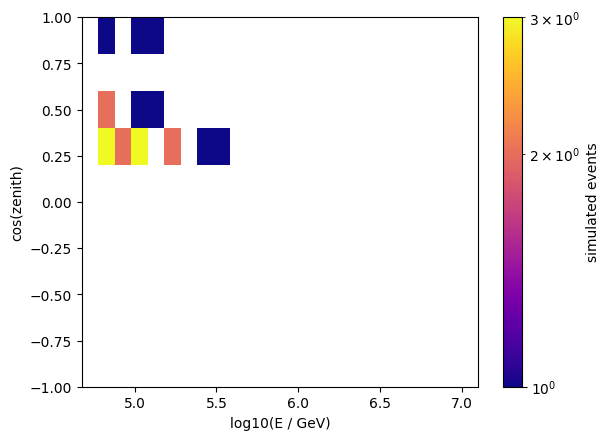

In [18]:
plt.figure()
h = plt.hist2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=None,
    bins=(bins_loge, bins_cos),
    norm=mpl.colors.LogNorm(),
cmap='plasma')

plt.colorbar(label='simulated events')
plt.xlabel('log10(E / GeV)')
plt.ylabel('cos(zenith)')
plt.savefig(f"{plotting_path}/unweighted.png")
plt.show()

## plot Flux weighted

Sum of MC expectation
4.954034029218301e-09 Hz
0.15623041714542835 per year


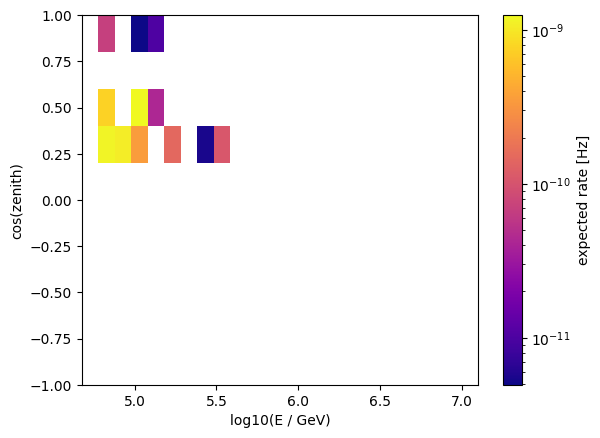

In [19]:
plt.figure()
h = plt.hist2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=weights,
    bins=(bins_loge, bins_cos),
norm=mpl.colors.LogNorm(),cmap='plasma')
print('Sum of MC expectation')
print(np.sum(h[0]), 'Hz')
print(np.sum(h[0])*365*24*3600, 'per year')

plt.colorbar(label='expected rate [Hz]')
plt.xlabel('log10(E / GeV)')
plt.ylabel('cos(zenith)')
plt.savefig(f"{plotting_path}/weighted.png")
plt.show()

# Try out smoothing with KDE

In [20]:
kde = KDEKernel.make_new_kernel(
    energy=reco_energy,
    zenith=reco_zenith,
    weights=weights,
    bounds=((4.5,7.1), (-1.1,1.2)),
    thresholds=((4.778,7), (-1, 1.1)),

    # default values from here
    useNevents=None,
    kde_values=None,
    use_cuda=False,
    niter=30,  # 10
    bootstrap=True,  # False
    adaptive=True,
    weight_adaptive_bw=True,  # False
    alpha=0.1,  # 0.3, 0.1
    # bw_method="scott"  # "silverman"
     bw_method="silverman"  # "silverman"
)

kde2 = None


In [21]:
bins_loge_centers = np.diff(bins_loge) / 2. + bins_loge[0:-1]
bins_cos_centers = np.diff(bins_cos) / 2. + bins_cos[0:-1]

X, Y = np.meshgrid(bins_loge_centers, bins_cos_centers)
XYpos = np.vstack([X.ravel(), Y.ravel()])

kde_evaluated = kde.func_rate_density(XYpos)

rate = np.reshape(kde_evaluated[0].T, X.shape)
rate_error = np.reshape(kde_evaluated[1].T, X.shape)

sum(sum(rate))

2.852521855889127e-07

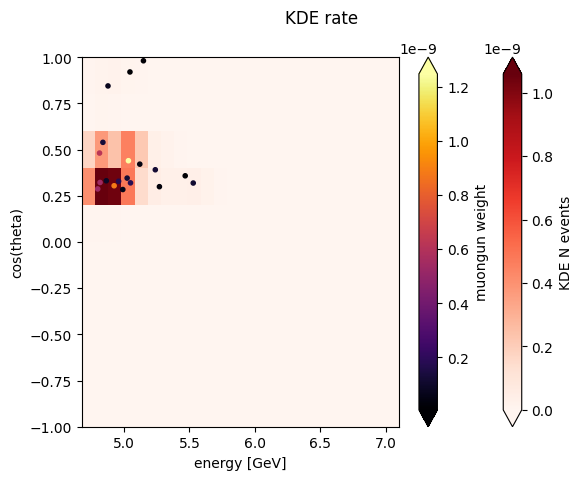

2.852521855889127e-07

In [22]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
fig.suptitle("KDE rate")

# plot
X_plot, Y_plot = np.meshgrid(bins_loge, bins_cos)
factor = weights.sum() / rate.sum()
pm = ax1.pcolormesh(X_plot, Y_plot, rate * factor, vmin=0, cmap="Reds")
plt.colorbar(pm, label="KDE N events", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.savefig(f"{plotting_path}/kde_rate.png")
plt.show()
sum(sum(rate))

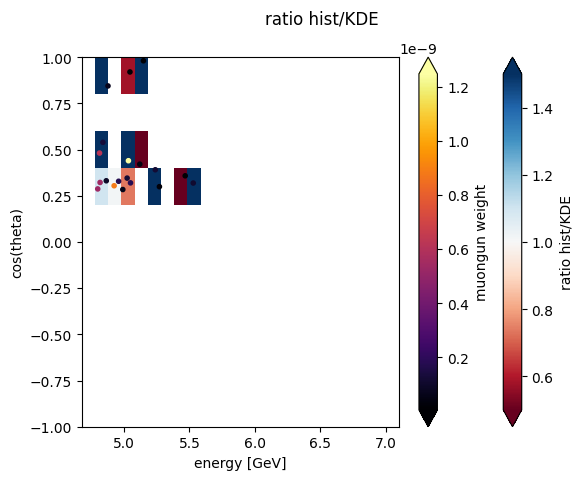

2.852521855889127e-07

In [23]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
fig.suptitle("ratio hist/KDE")

# muongun hist
hist, _, _ = np.histogram2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=weights,
    bins=(bins_loge, bins_cos),
)

# plot
X_plot, Y_plot = np.meshgrid(bins_loge, bins_cos)
ratio = hist.T / (rate * factor)
ratio[np.isclose(ratio, 0)] = np.NaN
pm = ax1.pcolormesh(X_plot, Y_plot, ratio, cmap="RdBu", vmin=0.5, vmax=1.5)
plt.colorbar(pm, label="ratio hist/KDE", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.savefig(f"{plotting_path}/ratio_hist_kde.png")
plt.show()
sum(sum(rate))

In [24]:
if kde2 is not None:

    # new figure
    fig, (ax1) = plt.subplots(1, 1)
    fig.suptitle("ratio KDE2/KDE")

    # KDE2
    kde_evaluated2 = kde2.func_rate_density(XYpos)
    rate2 = np.reshape(kde_evaluated2[0].T, X.shape)
    rate_error2 = np.reshape(kde_evaluated2[1].T, X.shape)

    # plot
    X_plot, Y_plot = np.meshgrid(bins_loge, bins_cos)
    ratio = (rate2 * factor) / (rate * factor)
    ratio[np.isclose(ratio, 0)] = np.NaN
    pm = ax1.pcolormesh(X_plot, Y_plot, ratio, cmap="RdBu_r", vmin=0, vmax=2)
    plt.colorbar(pm, label="ratio hist/KDE", extend='both')

    pc = ax1.scatter(
        x=np.log10(reco_energy),
        y=np.cos(reco_zenith),
        c=weights,
        cmap="inferno",
        marker="."
    )
    plt.colorbar(pc, label="muongun weight", extend='both')

    # setup figure
    ax1.set_xlabel("energy [GeV]")
    ax1.set_ylabel("cos(theta)")
    ax1.set_xlim(bins_loge[0], bins_loge[-1])
    plt.show()
sum(sum(rate))

2.852521855889127e-07

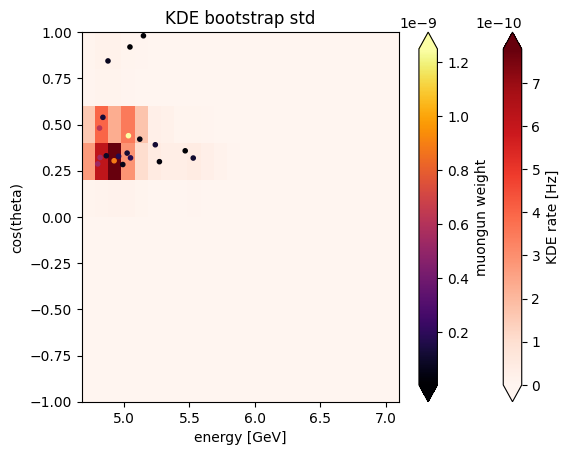

2.852521855889127e-07

In [25]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("KDE bootstrap std")

# plot
pm = ax1.pcolormesh(X_plot, Y_plot, rate_error * factor, cmap="Reds")
plt.colorbar(pm, label="KDE rate [Hz]", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.savefig(f"{plotting_path}/kde_bootstrap_std.png")
plt.show()
sum(sum(rate))

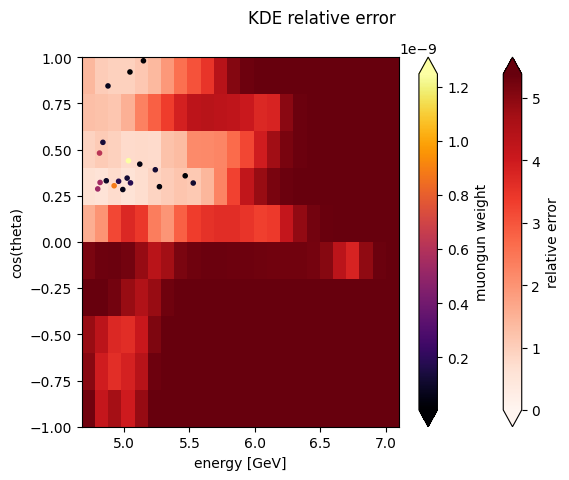

2.852521855889127e-07

In [26]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
fig.suptitle("KDE relative error")

# plot
pm = ax1.pcolormesh(X_plot, Y_plot, rate_error / rate, vmin=0,cmap="Reds")
plt.colorbar(pm, label="relative error", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.savefig(f"{plotting_path}/kde_relative_error.png")
plt.show()
sum(sum(rate))

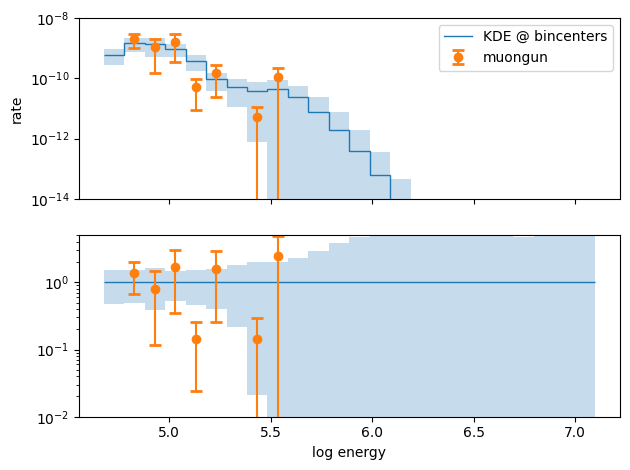

57.57977920751643

In [27]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=0)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=0))
plot_hist_band(ax1, hist=y, bins=bins_loge, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_loge, yerror=yerror, hist_baseline=y, color="C0")

# muongun
hist, hist_error = make_hist_error(np.log10(reco_energy), bins=bins_loge, weights=weights)
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_loge, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_loge, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

ax1.legend()
plt.xlabel("log energy")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(1e-2,5)
ax1.set_ylim(1e-14, 1e-8)

ax2.set_yscale("log")

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.2)
plt.savefig(f"{plotting_path}/rate_energy_kde_muongun.png")
plt.show()
sum(sum(rate))/sum(hist)

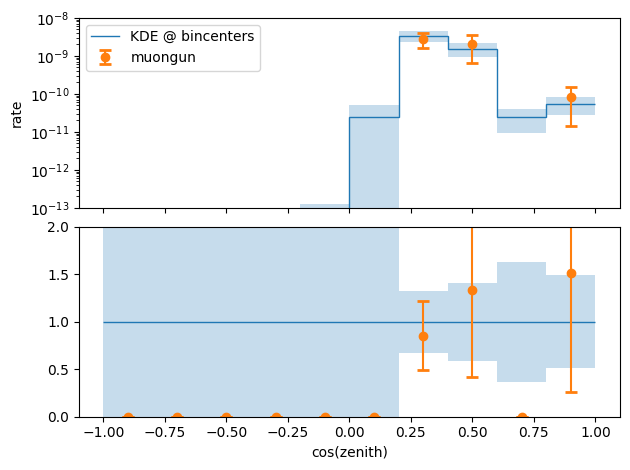

57.579779207516424

In [28]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=1)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=1))
plot_hist_band(ax1, hist=y, bins=bins_cos, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_cos, yerror=yerror, hist_baseline=y, color="C0")

# print(np.cos(reco_zenith)[reco_energy>=1000.])
# muongun
# hist, hist_error = make_hist_error(np.cos(reco_zenith)[reco_energy>=1000.], bins=bins_cos, weights=weights[reco_energy>=1000.])
hist, hist_error = make_hist_error(np.cos(reco_zenith), bins=bins_cos, weights=weights)

plot_data_hist_errorbar(ax1, hist=hist, bins=bins_cos, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_cos, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

ax1.legend()
plt.xlabel("cos(zenith)")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(0, 2)
ax1.set_ylim(1e-13, 1e-8)

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.1)
plt.savefig(f"{plotting_path}/rate_energy_kde_zenith.png")
plt.show()
sum(sum(rate))/sum(hist)

In [29]:
# define analysis binning: cscd_cascade
bins_analysis_loge = np.linspace(4.778, 7.1, 24)
bins_analysis_cos = np.linspace(-1,1,11)

analysis_shape = (len(bins_analysis_loge) - 1, len(bins_analysis_cos) - 1)

bins_analysis_loge_centers = np.mean(rolling_window(bins_analysis_loge, 2), axis=1)
bins_analysis_cos_centers = np.mean(rolling_window(bins_analysis_cos, 2), axis=1)

In [30]:
# finer bining
# spline_binning_x = np.linspace(3, 7, 118)#67
spline_binning_x = np.linspace(4.67704348, 7.1, 49)#67

# spline_binning_y = np.linspace(-1,1, 31)
spline_binning_y = np.linspace(-1,1,21)


# ensure finer bins include analysis bin edges
assert all([np.any(np.isclose(v, spline_binning_x)) for v in bins_analysis_loge])
assert all([np.any(np.isclose(v, spline_binning_y)) for v in bins_analysis_cos])

spline_values_x = np.mean(rolling_window(spline_binning_x, 2), axis=1)
spline_values_y = np.mean(rolling_window(spline_binning_y, 2), axis=1)
spline_shape = (len(spline_values_x), len(spline_values_y))

# make grid for KDE
grid_x, grid_y = np.meshgrid(spline_values_x, spline_values_y)
grid_xy = np.vstack([grid_x.ravel(), grid_y.ravel()])

# eval KDE for spline
kde_evaluated_fine = kde.func_rate_density(grid_xy)
rate_fine = np.reshape(kde_evaluated_fine[0].T, grid_x.shape)
rate_error_fine = np.reshape(kde_evaluated_fine[1].T, grid_x.shape)

# renorm rate
rescale_factor = weights.sum() / rate_fine.sum()
rate_fine *= rescale_factor
rate_error_fine *= rescale_factor

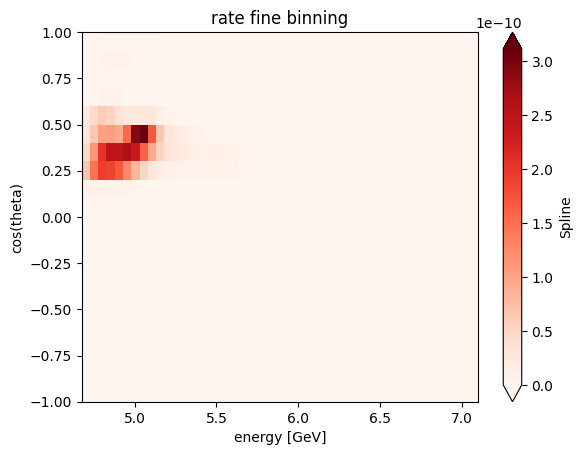

In [31]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("rate fine binning")

# plot
X_plot, Y_plot = np.meshgrid(spline_binning_x, spline_binning_y)
pm = ax1.pcolormesh(X_plot, Y_plot, rate_fine, vmin=0, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

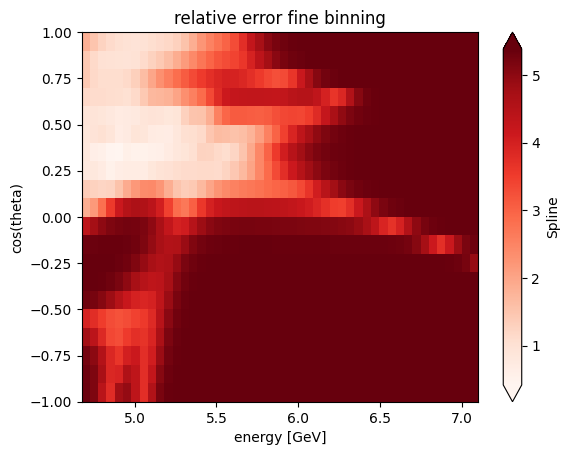

In [32]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("relative error fine binning")

# plot
X_plot, Y_plot = np.meshgrid(spline_binning_x, spline_binning_y)
pm = ax1.pcolormesh(X_plot, Y_plot, rate_error_fine/rate_fine, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

In [46]:
# sum up rate in anaylsis bins
integrated_rate = np.zeros(analysis_shape)
integrated_rate_error = np.zeros(analysis_shape)
integrated_rate_high_error = np.zeros(analysis_shape)
integrated_rate_low_error = np.zeros(analysis_shape)

# loop analysis bins
for idx_e, (emin, emax) in enumerate(rolling_window(bins_analysis_loge, 2)):
    for idx_z, (zmin, zmax) in enumerate(rolling_window(bins_analysis_cos, 2)):

        # get indices of fine bins within this analysis bin
        _, emin_idx = find_nearest(spline_binning_x, emin)
        _, emax_idx = find_nearest(spline_binning_x, emax)
        _, zmin_idx = find_nearest(spline_binning_y, zmin)
        _, zmax_idx = find_nearest(spline_binning_y, zmax)

        # build mask
        mask = np.zeros_like(rate_fine.T, dtype=bool)
        mask[emin_idx:emax_idx, zmin_idx:zmax_idx] = True

        integrated_rate[idx_e, idx_z] = np.sum(rate_fine.T[mask])        
        # integrated_rate_error[idx_e, idx_z] = np.sqrt(np.sum(rate_error_fine.T[mask]**2))

        # integrated_rate_error[idx_e, idx_z] = np.std(rate_fine.T[mask])
        # integrated_rate_error[idx_e, idx_z] = np.sqrt(np.mean(rate_error_fine.T[mask]**2))
        
        up = np.sum((rate_fine + rate_error_fine).T[mask])
        low = np.sum((rate_fine - rate_error_fine).T[mask])
        integrated_rate_error[idx_e, idx_z] = (up - low)
        integrated_rate_high_error[idx_e, idx_z] = up 
        integrated_rate_low_error[idx_e, idx_z] = low


# rescale_factor = weights.sum() / integrated_rate.sum()
# integrated_rate *= rescale_factor
# integrated_rate_error *= rescale_factor

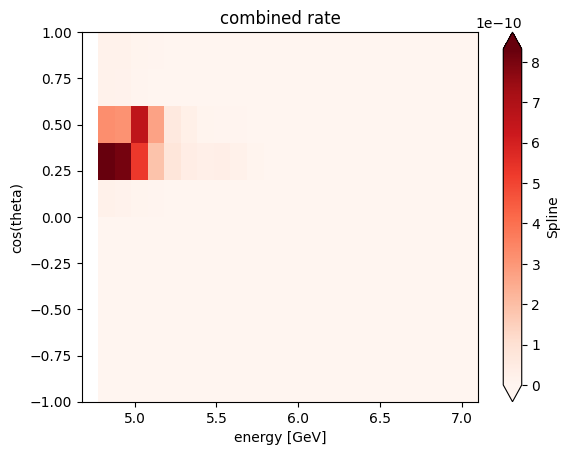

In [34]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("combined rate")

# plot
X_plot, Y_plot = np.meshgrid(bins_analysis_loge, bins_analysis_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, integrated_rate.T, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

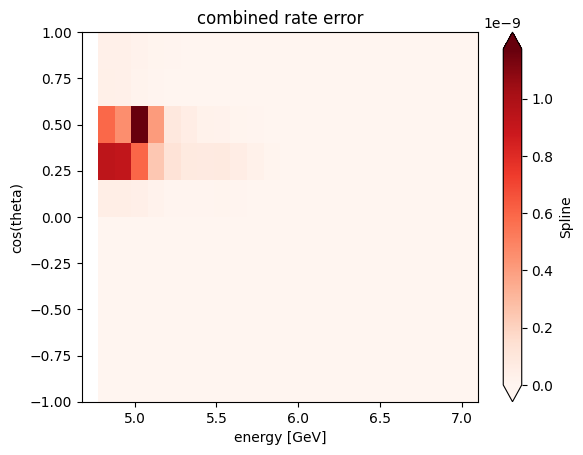

In [35]:
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("combined rate error")

# plot
X_plot, Y_plot = np.meshgrid(bins_analysis_loge, bins_analysis_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, integrated_rate_error.T, vmin=0, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

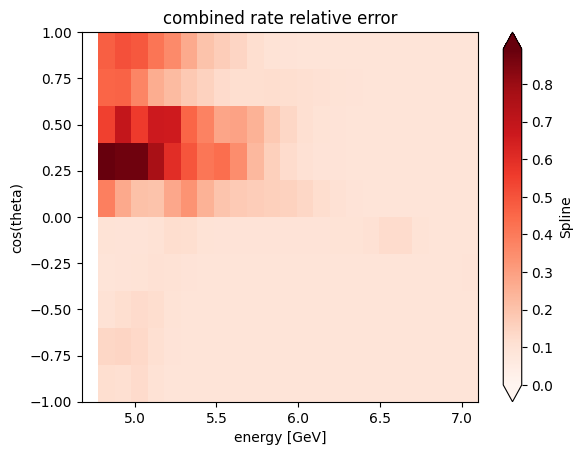

In [36]:
# new figure
fig, (ax1) = plt.subplots(1, 1)
ax1.set_title("combined rate relative error")

# plot
X_plot, Y_plot = np.meshgrid(bins_analysis_loge, bins_analysis_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, integrated_rate.T/integrated_rate_error.T, vmin=0, cmap="Reds")
plt.colorbar(pm, label="Spline", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

In [37]:
y

array([3.32867777e-34, 2.02137545e-27, 7.55039576e-22, 1.84428405e-17,
       4.76627409e-14, 2.49300246e-11, 3.31993309e-09, 1.52913062e-09,
       2.48472125e-11, 5.51453997e-11])

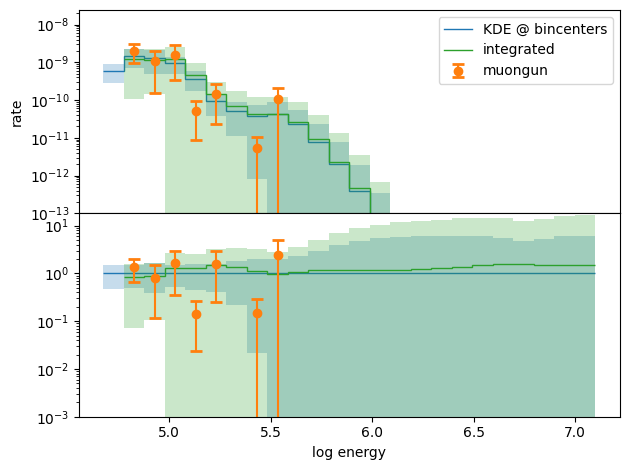

In [38]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=0)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=0))
plot_hist_band(ax1, hist=y, bins=bins_loge, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_loge, yerror=yerror, hist_baseline=y, color="C0")

# muongun
hist, hist_error = make_hist_error(np.log10(reco_energy), bins=bins_loge, weights=weights)
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_loge, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_loge, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

# integrated KDE
y_int = np.sum(integrated_rate, axis=1)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=1))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, hist_baseline=y[1:], color="C2")

# fine kde
# plot_hist_band(ax1, hist=np.sum(rate_fine.T, axis=1), bins=spline_binning_x, yerror=0, color="C3", label="fine kde")


ax1.legend()
plt.xlabel("log energy")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
# ax2.set_ylim(0, 4)
ax2.set_ylim(1e-3, None)
ax1.set_ylim(1e-13, None)
ax2.set_yscale("log")

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

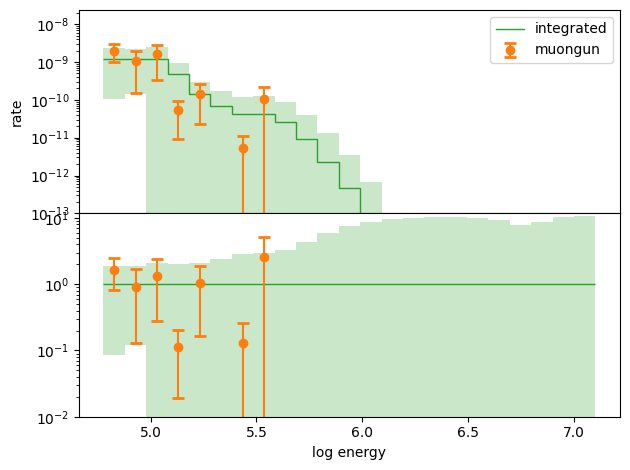

In [39]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# integrated KDE
y_int = np.sum(integrated_rate, axis=1)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=1))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_loge, yerror=yerror_int, hist_baseline=y_int, color="C2")

# muongun
hist, hist_error = make_hist_error(np.log10(reco_energy), bins=bins_loge, weights=weights)
plot_data_hist_errorbar(ax1, hist=hist[1:], bins=bins_loge[1:], yerror=hist_error[1:], color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist[1:], bins=bins_loge[1:], yerror=hist_error[1:], hist_baseline=y_int, color="C1", marker="o")


# fine kde
# plot_hist_band(ax1, hist=np.sum(rate_fine.T, axis=1), bins=spline_binning_x, yerror=0, color="C3", label="fine kde")


ax1.legend()
plt.xlabel("log energy")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
# ax2.set_ylim(0, 2)
ax2.set_ylim(1e-2, None)
ax1.set_ylim(1e-13, None)
ax2.set_yscale("log")

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

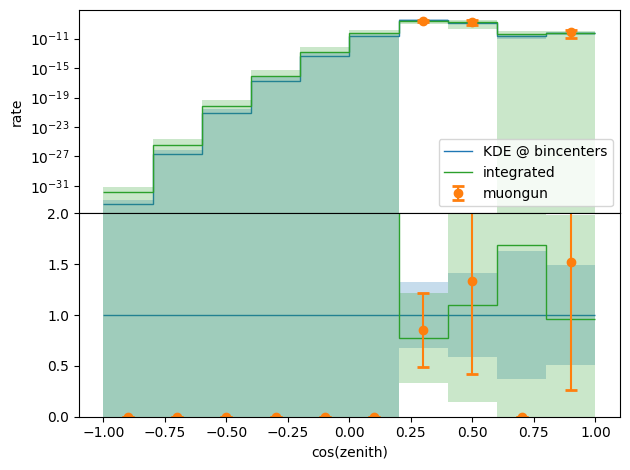

In [40]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# KDE
y = np.sum(rate*factor, axis=1)
yerror = np.sqrt(np.sum((rate_error*factor)**2, axis=1))
plot_hist_band(ax1, hist=y, bins=bins_cos, yerror=yerror, color="C0", label="KDE @ bincenters")
plot_ratio_band(ax2, hist=y, bins=bins_cos, yerror=yerror, hist_baseline=y, color="C0")

# muongun
hist, hist_error = make_hist_error(np.cos(reco_zenith)[reco_energy>=1000.], bins=bins_cos, weights=weights[reco_energy>=1000.])
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_cos, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_cos, yerror=hist_error, hist_baseline=y, color="C1", marker="o")

# integrated KDE
y_int = np.sum(integrated_rate, axis=0)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=0))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, hist_baseline=y, color="C2")

# fine kde
# plot_hist_band(ax1, hist=np.sum(rate_fine.T, axis=0), bins=spline_binning_y, yerror=0, color="C3", label="fine kde")


ax1.legend()
plt.xlabel("cos(zenith)")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(0, 2)

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

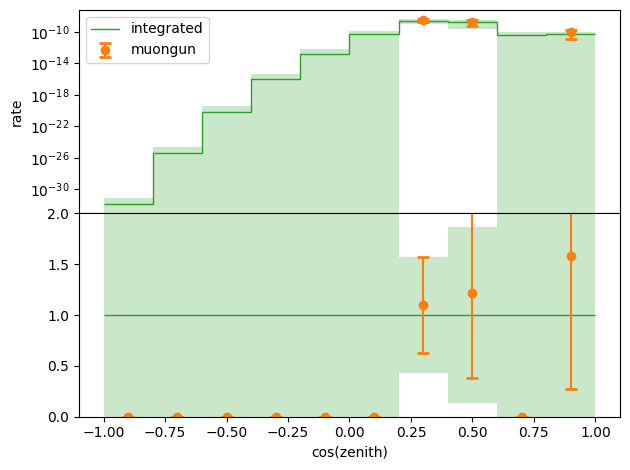

In [41]:
# new figure
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)


# integrated KDE
y_int = np.sum(integrated_rate, axis=0)
yerror_int = np.sqrt(np.sum(integrated_rate_error**2, axis=0))
plot_hist_band(ax1, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, color="C2", label="integrated")
plot_ratio_band(ax2, hist=y_int, bins=bins_analysis_cos, yerror=yerror_int, hist_baseline=y_int, color="C2")

# muongun
hist, hist_error = make_hist_error(np.cos(reco_zenith)[reco_energy>=1000.], bins=bins_cos, weights=weights[reco_energy>=1000.])
plot_data_hist_errorbar(ax1, hist=hist, bins=bins_cos, yerror=hist_error, color="C1", label="muongun", marker="o")
plot_data_ratio_errorbar(ax2, hist=hist, bins=bins_cos, yerror=hist_error, hist_baseline=y_int, color="C1", marker="o")


ax1.legend()
plt.xlabel("cos(zenith)")
ax1.set_ylabel("rate")
ax1.set_yscale("log")
ax2.set_ylim(0, 2)

# show
fig.tight_layout()
fig.subplots_adjust(hspace=0.0)
plt.show()

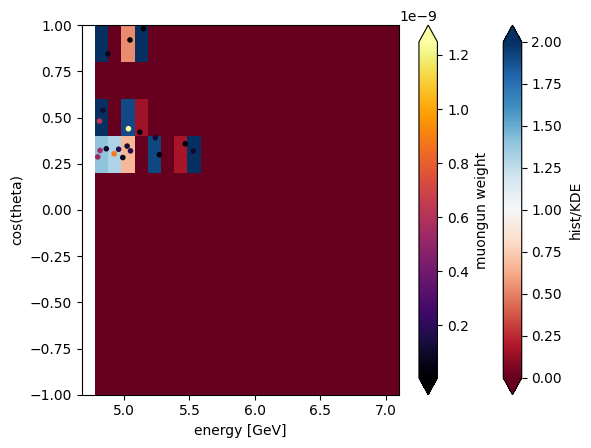

In [42]:
# new figure
fig, (ax1) = plt.subplots(1, 1)

# muongun hist
hist, _, _ = np.histogram2d(
    np.log10(reco_energy),
    np.cos(reco_zenith),
    weights=weights,
    bins=(bins_loge[1:], bins_cos),
)

# plot
X_plot, Y_plot = np.meshgrid(bins_loge[1:], bins_cos)
pm = ax1.pcolormesh(X_plot, Y_plot, hist.T/(integrated_rate.T), cmap="RdBu", vmin=0, vmax=2)
plt.colorbar(pm, label="hist/KDE", extend='both')

pc = ax1.scatter(
    x=np.log10(reco_energy),
    y=np.cos(reco_zenith),
    c=weights,
    cmap="inferno",
    marker="."
)
plt.colorbar(pc, label="muongun weight", extend='both')

# setup figure
ax1.set_xlabel("energy [GeV]")
ax1.set_ylabel("cos(theta)")
ax1.set_xlim(bins_loge[0], bins_loge[-1])
plt.show()

In [50]:
# set path
# outfile_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/muons/KDE/HESE_neha_Tracks_KDE.pickle"
outfile_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/muons/KDE/HESE_Tracks_KDE_11features_plus_rloglmilli_econf_evtgen_bdt1_0.333333_bdt2_0.366667_scaled.pickle"

to_dump = {
    "description" : "KDE for MuonGun generated using ####",
    
    
    "total_rate" : weights.sum(),
    
    "template" : np.fliplr(integrated_rate).flatten(),
    "template_fluctuation" : np.fliplr(integrated_rate_error).flatten(),
    
    # binning
    "energy_bins" : 10**bins_analysis_loge,
    
    "energy_bins_centers_log" : bins_analysis_loge_centers,
    "zenith_bins" : bins_analysis_cos,
    "zenith_bins_centers" : bins_analysis_cos_centers,
}
print(to_dump)

print(sum(np.fliplr(integrated_rate).flatten()), "Hz")
print(sum(np.fliplr(integrated_rate).flatten())*365*24*3600, "/ yr")
print(np.sum(integrated_rate_high_error*365*24*3600), "High / year")
print(np.sum(integrated_rate_low_error*365*24*3600), "Low / year")
print("+ error", np.sum(integrated_rate_high_error*365*24*3600) - sum(np.fliplr(integrated_rate).flatten())*365*24*3600 )
print("- error", sum(np.fliplr(integrated_rate).flatten())*365*24*3600 - np.sum(integrated_rate_low_error*365*24*3600) )

{'description': 'KDE for MuonGun generated using ####', 'total_rate': 4.954034029218301e-09, 'template': array([1.70504992e-11, 1.82414125e-11, 3.23788151e-10, 8.32495296e-10,
       2.02213371e-11, 1.37019438e-14, 1.31337535e-18, 2.82419352e-24,
       7.75664938e-31, 3.87737703e-38, 1.84188731e-11, 1.49423865e-11,
       3.14245363e-10, 8.07506327e-10, 1.40143560e-11, 2.54495522e-14,
       2.97286663e-18, 8.60829995e-24, 1.98661714e-30, 7.65126731e-38,
       9.32416058e-12, 5.51298291e-12, 6.57118315e-10, 5.26985519e-10,
       9.03599334e-12, 2.56700297e-14, 3.62168556e-18, 1.38194543e-23,
       3.92511693e-30, 3.53123890e-37, 4.82195831e-12, 2.03236209e-12,
       2.72535688e-10, 1.88352575e-10, 4.57755973e-12, 1.52512014e-14,
       2.56060740e-18, 1.56422657e-23, 1.91150386e-29, 2.90903762e-36,
       2.34829866e-12, 6.89995217e-13, 5.92423943e-11, 7.59466051e-11,
       2.26826935e-12, 6.95004748e-15, 1.80849062e-18, 5.25709297e-23,
       1.59073641e-28, 3.09966610e-35, 8.19

In [44]:
import pickle
pickle.dump(to_dump, open(outfile_path, "wb"))